## Investigate arm concentration of remote theta per theta cycle

In [1]:
# From position info:
# find a) animal speed > 4cm/s
#      b) when animal in outer arm

# From decode:
# find posterior in local arm sum less than 50%
# 
# For each theta cycle, get # of arms with >10% posterior
# For each theta cycle, get # of arms with >20% posterior
# For each theta cycle, get # of arms with >30% posterior

In [7]:
%reload_ext autoreload
%autoreload 2

In [8]:
import pandas as pd
# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import xarray as xr
import logging
import os
import cupy as cp
from scipy import linalg
import pickle

FORMAT = '%(asctime)s %(message)s'

logging.basicConfig(level='INFO', format=FORMAT, datefmt='%d-%b-%y %H:%M:%S')
from spyglass.decoding.v0.clusterless import ClusterlessClassifierParameters

In [24]:
from spyglass.shijiegu.Analysis_SGU import (EpochPos,TrialChoice,Decode,
    DecodeIngredients,DecodeResultsLinear,MUA,DecodeIngredientsLikelihood,
    DecodeResultsLinear,ChangeofMindRemoteTheta)
from spyglass.shijiegu.changeOfMind_figures.supp_decode import return_diff_file
from spyglass.linearization.v0.main import IntervalLinearizedPosition
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.shijiegu.decodeHelpers import session2position_name

from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.ripple_add_replay import select_subset_helper_pd, select_subset_helper
from spyglass.shijiegu.changeOfMind_helper import nodes
from spyglass.shijiegu.ripple_add_replay import position_posterior2arm_posterior
from spyglass.shijiegu.changeOfMind_triggered import linear_map
from spyglass.shijiegu.changeOfMind_figures.supp_thetacycle_concentration import return_concentration_session, return_concentration_day

In [25]:
list_of_days_animals = {}
encoding_set_animals = {}
classifier_param_name_animals = {}
seq_animals = {}
success_animal = {}

animal = 'eliot'
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'molly'
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

animal = "julio"
list_of_days_animals[animal] = ['20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "klein"
list_of_days_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108','20231109','20231111']
seq_animals[animal] = 'rev2'
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

bad_sessions = [] # these sessions have incomplete number of sorted tetrodes

In [ ]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure_supp_decode'

for animal in list_of_days_animals:

    concentration_dict_all_trials, theta_cycle_num_all_trials = return_concentration_day(
        animal, list_of_days_animals[animal])
    
    data = {"concentration_dict": concentration_dict_all_trials, 
            "theta_cycle_num": theta_cycle_num_all_trials}
    
    data_filename = f"theta_cycle_arm_concentration_{animal}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {output_path}")

#concentration_dict_all_trials, theta_cycle_num_all_trials = return_concentration_session('eliot20221021_.nwb', "02_Seq2Session1")

[2026-03-24 16:12:28,049][WARNING]: Skipped checksum for file with hash: 7e3711a5-f3a3-093e-6cf2-2d83e442c10b, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_8EGEKU4O48.nwb
24-Mar-26 16:12:28 Skipped checksum for file with hash: 7e3711a5-f3a3-093e-6cf2-2d83e442c10b, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_8EGEKU4O48.nwb


Processing eliot 20221018 session: 02_Seq2Session1 per theta cycle
Processing eliot20221018_.nwb session: 02_Seq2Session1


[2026-03-24 16:12:39,597][WARNING]: Skipped checksum for file with hash: 3b2d93a0-f420-7cfe-1ce9-c2fba7880815, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_9FVCVSINVL.nwb
24-Mar-26 16:12:39 Skipped checksum for file with hash: 3b2d93a0-f420-7cfe-1ce9-c2fba7880815, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_9FVCVSINVL.nwb


Processing eliot 20221018 session: 04_Seq2Session2 per theta cycle
Processing eliot20221018_.nwb session: 04_Seq2Session2
No triggered decode found for  {'nwb_file_name': 'eliot20221018_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
Processing eliot 20221018 session: 05_Seq2Session3 per theta cycle
Processing eliot20221018_.nwb session: 05_Seq2Session3


[2026-03-24 16:12:50,855][WARNING]: Skipped checksum for file with hash: 70da43fd-50e5-f2b2-4cf1-28dc12ea576b, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_DHXOAEXUO5.nwb
24-Mar-26 16:12:50 Skipped checksum for file with hash: 70da43fd-50e5-f2b2-4cf1-28dc12ea576b, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_DHXOAEXUO5.nwb


...

Processing eliot 20221019 session: 06_Seq2Session3 per theta cycle
Processing eliot20221019_.nwb session: 06_Seq2Session3


[2026-03-24 16:14:05,050][WARNING]: Skipped checksum for file with hash: 6f72046e-0bee-5923-ca2b-b3c928fccf1c, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_MGNPGK31S3.nwb
24-Mar-26 16:14:05 Skipped checksum for file with hash: 6f72046e-0bee-5923-ca2b-b3c928fccf1c, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_MGNPGK31S3.nwb


Processing eliot 20221019 session: 08_Seq2Session4 per theta cycle
Processing eliot20221019_.nwb session: 08_Seq2Session4


[2026-03-24 16:14:20,120][WARNING]: Skipped checksum for file with hash: 2b663e8c-9618-95f6-1042-0ca1a9773f3f, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_IZ04CGIMIB.nwb
24-Mar-26 16:14:20 Skipped checksum for file with hash: 2b663e8c-9618-95f6-1042-0ca1a9773f3f, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_IZ04CGIMIB.nwb


Processing eliot 20221019 session: 10_Seq2Session5 per theta cycle
Processing eliot20221019_.nwb session: 10_Seq2Session5


Data loaded from /stelmo/shijie/change_of_mind_analysis/figure_supp_decode/theta_cycle_arm_concentration_eliot.pkl
Data loaded from /stelmo/shijie/change_of_mind_analysis/figure_supp_decode/theta_cycle_arm_concentration_lewis.pkl
Data loaded from /stelmo/shijie/change_of_mind_analysis/figure_supp_decode/theta_cycle_arm_concentration_molly.pkl
Data loaded from /stelmo/shijie/change_of_mind_analysis/figure_supp_decode/theta_cycle_arm_concentration_julio.pkl
Data loaded from /stelmo/shijie/change_of_mind_analysis/figure_supp_decode/theta_cycle_arm_concentration_klein.pkl


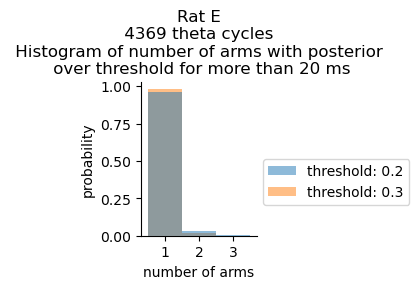

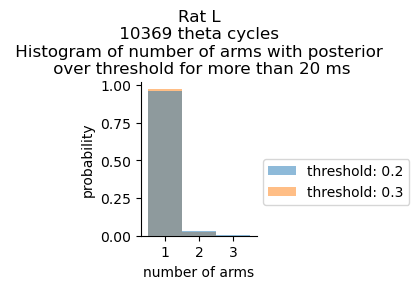

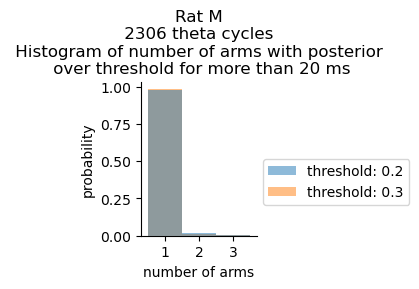

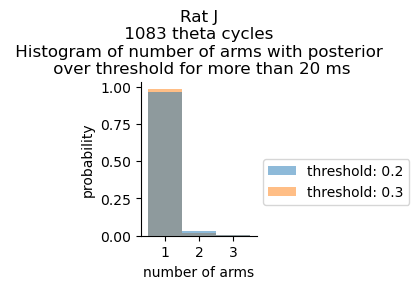

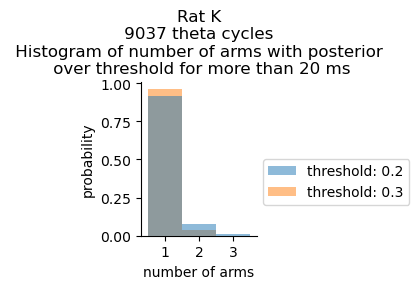

In [30]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure_supp_decode'
figure_outputfolder = '/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp_decode/'

for animal in ["eliot","lewis","molly","julio","klein"]:

    data_filename = f"theta_cycle_arm_concentration_{animal}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {output_path}")
    
    concentration_dict = data["concentration_dict"]
    theta_cycle_num = data["theta_cycle_num"]
    
    # plotting
    fig, axes = plt.subplots(1, 1, figsize=(1.5, 2),sharey = True)
    
    plot_ind = 0
    for threshold in [0.2, 0.3]:
        plot_data = np.array(concentration_dict[threshold])
        N = len(plot_data)
        plot_data = plot_data[plot_data > 0]
        axes.hist(plot_data,
                      weights = np.ones_like(plot_data)/len(plot_data),
                      bins = [0,1,2,3,4],
                      alpha = 0.5,
                      label = f"threshold: {threshold}",
                      zorder = 100-plot_ind,
                     )
        #axes.text(4.5,0.5-0.1*(plot_ind),f"{threshold}: # of theta cycles: {N}") #something about the amount of data going in
        plot_ind+=1
    
    axes.set_xticks(np.array([1,2,3]) + 0.5)
    axes.set_xticklabels(np.array([1,2,3]))
    axes.set_xlim([0.8,4.2])
    axes.spines[['right', 'top']].set_visible(False)
    
    axes.legend(bbox_to_anchor=(1.05, 0.5), loc='upper left', borderaxespad=0.)
    axes.set_xlabel("number of arms")
    axes.set_ylabel("probability")
    axes.set_title(f"Rat {animal[0].upper()}\n {N} theta cycles \n Histogram of number of arms with posterior \n over threshold for more than 20 ms")

    plt.savefig(os.path.join(figure_outputfolder,
        f'thetacycle_decode_concentration_by_arm_histogram{animal}.pdf'),dpi=300,bbox_inches='tight')


Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/theta_cycle_arm_concentration_eliot.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/theta_cycle_arm_concentration_lewis.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/theta_cycle_arm_concentration_molly.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/theta_cycle_arm_concentration_julio.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/theta_cycle_arm_concentration_klein.pkl


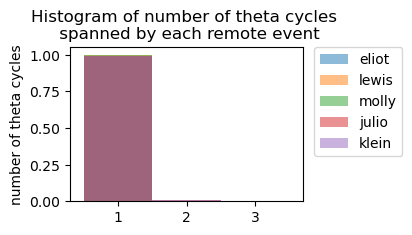

In [80]:
fig, axes = plt.subplots(1, 1, figsize=(3, 2),sharey = True)

for animal in ["eliot","lewis","molly","julio","klein"]:

    data_filename = f"theta_cycle_arm_concentration_{animal}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {output_path}")

    theta_cycle_num = data["theta_cycle_num"]


    plot_data = np.array(theta_cycle_num)
    plot_data = plot_data[plot_data > 0]
    axes.hist(plot_data,
             weights = np.ones_like(plot_data)/len(plot_data),
             bins = [0,1,2,3,4],
             alpha = 0.5,
            label = animal,
             )
    
axes.set_xticks(np.array([1,2,3]) + 0.5)
axes.set_xticklabels(np.array([1,2,3]))
axes.set_xlim([0.8,4.2])

axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axes.set_ylabel("number of theta cycles")
axes.set_title(f"Histogram of number of theta cycles \n spanned by each remote event")
    
plt.savefig(f'thetacycle_decode_concentration_{animal}.pdf',dpi=300,bbox_inches='tight')

In [38]:
concentration_dict_all_trials

{0.15: [2, 2, 3, 3, 1, 2, 2, 2],
 0.2: [2, 2, 1, 2, 1, 2, 2, 2],
 0.3: [2, 1, 1, 1, 1, 1, 2, 2]}

In [39]:
theta_cycle_num_all_trials

[1, 1, 1, 1, 1, 1, 1, 1]

In [34]:
#%debug

In [22]:
theta_cycle_num_all_trials

[0, 0, 1, 0, 0, 0, 0, 0]

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220418_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control0_allposterior.pkl':
Processing molly 20220418 session: 02_Seq2Session1
Processing molly 20220418 session: 04_Seq2Session2
Processing molly 20220418 session: 06_Seq2Session3
Processing molly 20220418 session: 08_Seq2Session4
Processing molly 20220418 session: 10_Seq2Session5


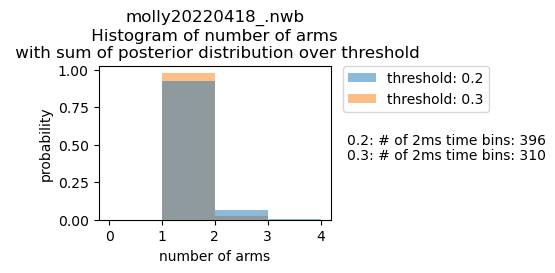

In [199]:
for nwb_copy_file_name in nwb_copy_file_name_all:
    animal = nwb_copy_file_name[:5]
    day = nwb_copy_file_name[5:13]
    local_concentration_day, nonlocal_concentration_day = return_concentration_day(animal, day)

    # plotting
    fig, axes = plt.subplots(1, 1, figsize=(3, 2),sharey = True)

    plot_ind = 0
    for threshold_nonlocal in [0.2, 0.3]:
        plot_data = nonlocal_concentration_day[threshold_nonlocal]
        plot_data = plot_data[plot_data > 0]
        axes.hist(plot_data,
                  weights = np.ones_like(plot_data)/len(plot_data),
                  bins = [0,1,2,3,4],
                  alpha = 0.5,
                  label = f"threshold: {threshold_nonlocal}",
                  zorder = 100-plot_ind,
                 )
        axes.text(4.5,0.5-0.1*(plot_ind),f"{threshold_nonlocal}: # of 2ms time bins: {len(plot_data)}") #something about the amount of data going in
        plot_ind+=1
    
    axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    axes.set_xlabel("number of arms")
    axes.set_ylabel("probability")
    axes.set_title(f"{nwb_copy_file_name}\n Histogram of number of arms \n with sum of posterior distribution over threshold")
    
    plt.savefig(f'decode_concentration_{nwb_copy_file_name}.pdf',dpi=300,bbox_inches='tight')

In [190]:
#%debug

In [186]:
DecodeResultsLinear()

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,classifier_param_name a name for this set of parameters,encoding_set a name for this set of encoding,posterior posterior within that interval (1D)
eliot20221017_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221017_.nwb,04_Seq2Session2,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221017_.nwb,06_Seq2Session3,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221017_.nwb,08_Seq2Session4,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221018_.nwb,02_Seq2Session1,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221018_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221018_.nwb,04_Seq2Session2,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221018_.nwb,04_Seq2Session2,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221018_.nwb,05_Seq2Session3,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221018_.nwb,05_Seq2Session3,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=


In [164]:
nwb_copy_file_name

'lewis20240109_.nwb'

In [26]:
ind = 0
nwb_copy_file_name = nwb_copy_file_name_all[ind]
session_name = sessions_all[ind]

animal = nwb_copy_file_name[:5]
d = nwb_copy_file_name[5:13]
if animal == "eliot":
    encoding_set = '2Dheadspeed_above_4_andlowmua'
    classifier_param_name = 'default_decoding_gpu_4armMaze'
else:
    encoding_set = '2Dheadspeed_above_4'
    classifier_param_name = 'default_decoding_gpu_4armMaze'

# load decode
decode_path = (DecodeResultsLinear & {"nwb_file_name":nwb_copy_file_name,
                           "interval_list_name":session_name,
                           "classifier_param_name":classifier_param_name}).fetch1("posterior")
decode = xr.open_dataset(decode_path)
    
## load LinearPosition
pos1d = pd.read_csv((DecodeIngredients & {"nwb_file_name":nwb_copy_file_name,
                                   "interval_list_name":session_name}).fetch1("position_1d"))
    
pos2d = pd.read_csv((DecodeIngredients & {"nwb_file_name":nwb_copy_file_name,
                                   "interval_list_name":session_name}).fetch1("position_2d"))

# load dataset
paramters = {"proportion":0.1,
              "delta_t_minus":5,
              "delta_t_plus":5,
              "max_flag":1,
              "segment_only":False,
              "multiple_CoM":True, "single_CoM":True, "first_CoM":False
            }

# load dataset
loaded_data = load_triggered_position_decode_day(animal, d, encoding_set, classifier_param_name,
                                                         control = False,
                                                         **paramters)

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/lewis_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240109_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control0_allposterior.pkl':


In [53]:
position_ind = 0
triggered_position = triggered_positions[position_ind]

In [51]:
triggered_trial_info = loaded_data["triggered_trial_info"]

session_ind = np.array([ind for ind in range(len(triggered_trial_info)) if triggered_trial_info[ind][1] == session_name])

triggered_positions = [loaded_data["triggered_positions_baseoff"][ind] for ind in session_ind]
triggered_trial_info = np.array(triggered_trial_info)[session_ind]

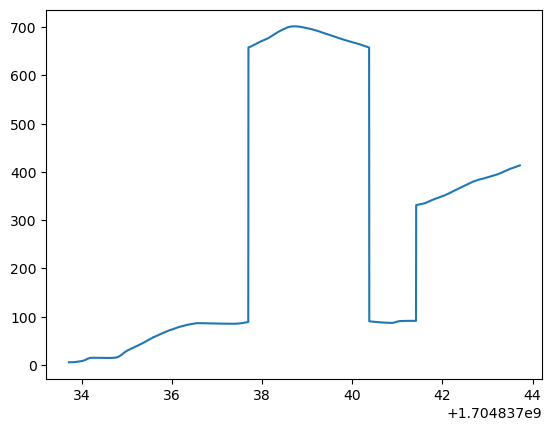

In [54]:
plt.plot(triggered_position)

In [57]:
triggered_position.index

Index([1704837033.7182767, 1704837033.7202768, 1704837033.7222767,
       1704837033.7242768, 1704837033.7262766, 1704837033.7282767,
       1704837033.7302768, 1704837033.7322767, 1704837033.7342768,
       1704837033.7362766,
       ...
       1704837043.7002742,  1704837043.702274, 1704837043.7042742,
       1704837043.7062743, 1704837043.7082741, 1704837043.7102742,
        1704837043.712274, 1704837043.7142742, 1704837043.7162743,
        1704837043.718274],
      dtype='float64', name='time', length=5001)

In [77]:
# From position info:
# find a) animal speed > 4cm/s
#      b) when animal in outer arm > proportion 0.1

t0t1 = [triggered_position.index[0], triggered_position.index[-1]]
subset_ind = (pos1d.time >= t0t1[0]) & (pos1d.time <= t0t1[1])
pos1d_subset = pos1d.loc[subset_ind]
pos2d_subset = pos2d.loc[subset_ind]

# speed thresholding
ind = pos2d_subset.head_speed >= 4
pos1d_subset = pos1d_subset[ind]
pos2d_subset = pos2d_subset[ind]

# 
ind = pos1d_subset.track_segment_id >= 5
pos1d_subset = pos1d_subset[ind]
pos2d_subset = pos2d_subset[ind]

In [88]:
# b) when animal in outer arm > proportion 0.1
track_segment_node_start = np.array([nodes[i][0] for i in np.array(pos1d_subset.track_segment_id)])
track_segment_node_end = np.array([nodes[i][1] for i in np.array(pos1d_subset.track_segment_id)])

projected_xy = np.hstack((np.array(pos1d_subset.projected_x_position).reshape((-1,1)),
                                        np.array(pos1d_subset.projected_y_position).reshape((-1,1))))
    
full_length = linalg.norm(track_segment_node_start - track_segment_node_end, axis = 1)
partial_length = linalg.norm(track_segment_node_start - projected_xy, axis = 1)
proportion = partial_length / full_length

ind = proportion >= 0.1
pos1d_subset = pos1d_subset[ind]
pos2d_subset = pos2d_subset[ind]

In [91]:
decode_subset = decode.isel(time = pos2d_subset.index)

In [93]:
posterior_position_subset = decode_subset.causal_posterior.sum(dim='state')

In [124]:
posterior_by_arm = position_posterior2arm_posterior(posterior_position_subset,linear_map)
arm_id = np.array(pos1d_subset.track_segment_id - 5).astype("int")
posterior_local = np.array([posterior_by_arm[arm_id[t_ind], t_ind] for t_ind in range(len(arm_id))])


In [139]:
threshold = 0.5
time_ind = np.argwhere(posterior_local <= threshold).ravel()

In [151]:
thresholds_nonlocal = [0.1, 0.2, 0.3]

posteriors_nonlocal = {}
for threshold_nonlocal in thresholds_nonlocal:
    posteriors_nonlocal[threshold_nonlocal] = np.array(
        [np.sum(posterior_by_arm[:,t_ind][np.setdiff1d([0,1,2,3,4],arm_id[t_ind])] >= threshold_nonlocal) for t_ind in time_ind]
    )

Text(0.5, 1.0, 'Histogram of number of arms \n with sum of posterior distribution over threshold')

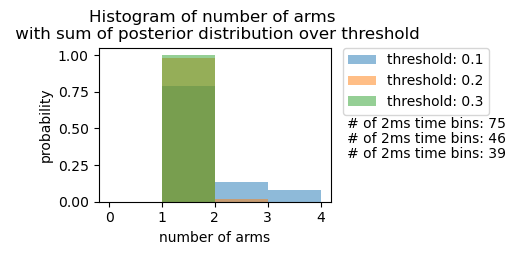

In [162]:
fig, axes = plt.subplots(1, 1, figsize=(3, 2),sharey = True)

plot_ind = 0
for threshold_nonlocal in posteriors_nonlocal.keys():
    plot_data = posteriors_nonlocal[threshold_nonlocal]
    plot_data = plot_data[plot_data > 0]
    axes.hist(plot_data,
              weights = np.ones_like(plot_data)/len(plot_data),
              bins = [0,1,2,3,4],
              alpha = 0.5,
              label = f"threshold: {threshold_nonlocal}"
             )
    axes.text(4.5,0.5-0.1*(plot_ind),f"# of 2ms time bins: {len(plot_data)}") #something about the amount of data going in
    plot_ind+=1

axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axes.set_xlabel("number of arms")
axes.set_ylabel("probability")
axes.set_title("Histogram of number of arms \n with sum of posterior distribution over threshold")

(array([  26.,   44.,   41.,   30.,   34.,   33.,   56.,   71.,  225.,
        1545.]),
 array([0.00763639, 0.10687277, 0.20610914, 0.30534551, 0.40458187,
        0.50381827, 0.60305464, 0.70229101, 0.80152738, 0.90076375,
        1.00000012]),
 <BarContainer object of 10 artists>)

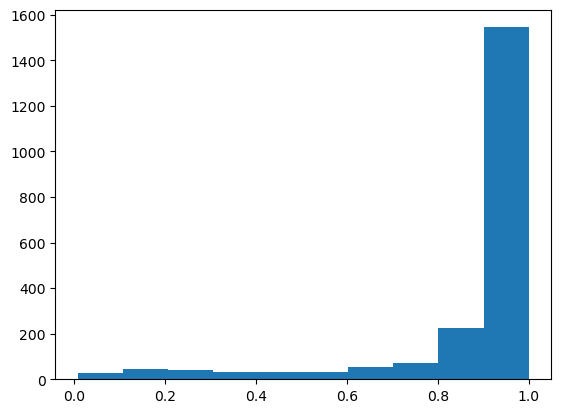

In [121]:
plt.hist(posterior_local)

3.0

In [89]:
pos1d_subset.track_segment_id

,time,linear_position,track_segment_id,projected_x_position,projected_y_position
112577,1.704837e+09,666.296618,9.0,241.465658,144.255267
112578,1.704837e+09,666.383116,9.0,241.543475,144.217499
112579,1.704837e+09,666.469613,9.0,241.621291,144.179732
112580,1.704837e+09,666.556110,9.0,241.699108,144.141964
112581,1.704837e+09,666.642608,9.0,241.776924,144.104196
...,...,...,...,...,...
115489,1.704837e+09,413.277053,7.0,187.394873,59.317346
115490,1.704837e+09,413.340775,7.0,187.377151,59.256139
115491,1.704837e+09,413.404496,7.0,187.359428,59.194932
115492,1.704837e+09,413.468217,7.0,187.341705,59.133725


In [90]:
pos2d_subset

,time,head_position_x,head_position_y,head_orientation,head_velocity_x,head_velocity_y,head_speed
112577,1.704837e+09,240.554924,142.378788,-0.171753,41.023714,-18.811027,45.130919
112578,1.704837e+09,240.636364,142.348485,-0.170437,41.003073,-18.815165,45.113883
112579,1.704837e+09,240.717803,142.318182,-0.169119,40.980772,-18.819121,45.095266
112580,1.704837e+09,240.799242,142.287879,-0.167798,40.956876,-18.822904,45.075131
112581,1.704837e+09,240.880682,142.257576,-0.166474,40.931450,-18.826524,45.053541
...,...,...,...,...,...,...,...
115489,1.704837e+09,189.714015,58.645833,-1.746752,-10.237362,-28.744696,30.513294
115490,1.704837e+09,189.700758,58.583333,-1.744697,-10.221937,-28.642136,30.411510
115491,1.704837e+09,189.687500,58.520833,-1.742638,-10.205830,-28.537695,30.307738
115492,1.704837e+09,189.674242,58.458333,-1.740574,-10.189019,-28.431368,30.201966


In [29]:


    

decode_subset = decode.isel(time = pos2d_subset.index)


# From decode:
# find posterior in local arm sum less than 50%
# 
# For each bin, get # of arms with >10% posterior
# For each bin, get # of arms with >20% posterior
# For each bin, get # of arms with >30% posterior
